In [38]:
# Open node.log and extract the data from it
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout

def parse_input(input_data):
    edges = []
    labels = {}
    
    lines = input_data.strip().split('\n')
    for line in lines:
        parts = line.split(' ')
        if parts[0].startswith('State'):
            state_id = int(parts[0].split('[')[1].split(']')[0])
            state_name = line.split('name(')[1].split(')')[0]
            labels[state_id] = state_name
        elif parts[0].startswith('Node'):
            node_id = int(parts[0].split('[')[1].split(']')[0])
            parent_id = int(parts[-1].split('(')[1].split(')')[0])
            edges.append((parent_id, node_id))

    return edges, labels

def create_graph(edges, labels):
    # Create a directed graph
    G = nx.DiGraph()

    # Add edges to the graph
    G.add_edges_from(edges)

    # Set the labels
    pos = nx.spring_layout(G, seed=42)  # Use spring layout for better organization
    nx.draw(G, pos, with_labels=True, labels={node: labels.get(node, node) for node in G.nodes()}, node_size=2000, node_color="lightblue", font_size=10, font_weight="bold")
    plt.title("Graph Representation of States and Nodes")
    plt.show()

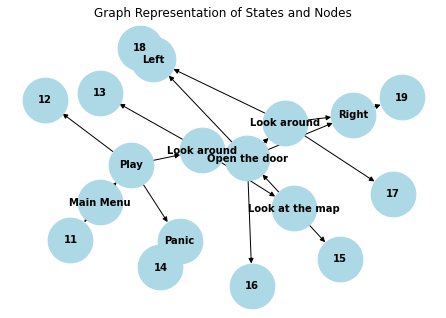

In [39]:
# open the file and parse the data
with open('node.log', 'r') as file:
    input_data = file.read()
    edges, labels = parse_input(input_data)
    create_graph(edges, labels)

[
    Event(id=1, parent=-1, name='Root', children=[
        Manager(id=0, parent=1, state=0, children=[
            State(id=0, parent=0, name='Main Menu', children=[
                Node(id=1, parent=0), Node(id=11, parent=0),
            ]),
            State(id=1,parent=0, name='Play', children=[
                Node(id=2, parent=1),
                Node(id=3, parent=1),
                Node(id=12, parent=1)
            ]),
            State(id=2, parent=0, name='Look around', children=[
                Node(id=4, parent=2),
                Node(id=5, parent=2),
                Node(id=13, parent=2)
            ]),
            State(id=3, parent=0, name='Panic',children=[
                Node(id=14, parent=3)
            ]),
            State(id=4, parent=0, name='Look at the map', children=[
                Node(id=5, parent=4),
                Node(id=15, parent=4)
            ]),
            State(id=5, parent=0, name='Open the door', children=[
                Node(id=6, parent=5),
                Node(id=7, parent=5),
                Node(id=8, parent=5),
                Node(id=16, parent=5)
            ]),
            State(id=6, parent=0, name='Look around', children=[
                Node(id=7, parent=6),
                Node(id=8, parent=6),
                Node(id=17, parent=6)
            ]),
            State(id=7, parent=0, name='Left', children=[
                Node(id=18, parent=7)
            ]),
            State(id=8, parent=0, name='Right', children=[
                Node(id=19, parent=8)
            ])
        ]),
    ])
]